# **Transfer Learning Recap Notes**

## 1. Introduction  

### What is Transfer Learning?  

<img src="https://www.frontiersin.org/files/Articles/381775/fnins-12-00491-HTML/image_m/fnins-12-00491-g001.jpg" alt="Neural Network Transfer Learning" height="200"/>

<img src="https://framerusercontent.com/images/7INIdkIR6fGLVB3OKx3SACpwkI.png" alt="Neural Network Difference" height="200"/>

Transfer Learning is a technique where a model trained on one task is reused for another related task.  
Instead of training from scratch, we take a **pre-trained model** and adapt it.  

Think of it like:  
- Learning to ride a **motorbike** is easier if you already know how to ride a **bicycle**.  

- The basic balance knowledge transfers, but you fine-tune the new skills.  

### Why Use Transfer Learning?  
- **Saves Time**: Skip training from scratch.  

- **Needs Less Data**: Works well even with smaller datasets.  

- **Better Accuracy**: Pre-trained models already know useful patterns.  

### When NOT to use it:  
- If the **source and target domains are very different** (e.g., natural photos → medical X-rays).  

- If you already have a **large labeled dataset** for your specific task.  

## 2. Glossary  

- **Pre-trained Model**: A model already trained on a huge dataset (e.g., ImageNet, Wikipedia).  

- **Fine-tuning**: Training a pre-trained model further on your dataset.  

- **Feature Extraction**: Using the pre-trained model only to get features, without retraining all layers.  

- **Frozen Layers**: Layers whose weights are not updated during training.  

- **Domain Adaptation**: Adjusting a model trained in one domain (e.g., photos) to work in another (e.g., medical scans).  

## 3. Transfer Learning Pipeline 

<img src="https://blogs.mathworks.com/deep-learning/files/2023/06/transfer_learning.png" alt="Transfer Learning Pipeline" height="200"/>

1. **Get Pre-trained Network**  
   - Choose a model already trained on a large dataset (e.g., ImageNet, Wikipedia).  
   - Match input format (e.g., image size, normalization, tokenization).  

2. **Modify Network**  
   - Replace the final layers so it matches your new task (e.g., new number of classes).  
   - Pick suitable activation/loss functions (e.g., softmax + cross-entropy).  

3. **Prepare New Data**  
   - Preprocess your dataset (resize, normalize using same stats as pre-training).  
   - Split carefully into train, validation, and test sets.  

4. **Retrain Network**  
   - Start by **freezing most layers** and training only the new head (**Feature Extraction**).  
   - Optionally, unfreeze deeper layers and **Fine-tune** with a smaller learning rate.  
   - Use **different learning rates**: small for pre-trained base, larger for new layers.  
   - Use **early stopping, checkpoints, and GPU/TPU acceleration**.  

5. **Predict on New Data**  
   - Evaluate with metrics like **accuracy, F1-score, confusion matrix**.  

## 4. Training Strategies

<img src="https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/Freeze-layers.png" alt="Freeze" height="200"/>

<img src="https://www.researchgate.net/publication/363776384/figure/fig1/AS:11431281122729387@1677516461009/Strategies-of-transfer-learning-112.jpg" alt="Strategy Comparison" height="200"/>

1. **Feature Extraction**  
   - Freeze pre-trained layers, train only new classification head.  
   - Faster, works well with small datasets.  

2. **Fine-tuning**  
   - Unfreeze some deeper layers and train with a small learning rate.  
   - Slower but can boost accuracy if you have enough data.  

3. **Hybrid Approach**  
   - Start with Feature Extraction.  
   - Later unfreeze some layers and Fine-tune.  
   - Good balance of speed and performance.  

4. **Differential Learning Rates**  
   - Apply smaller learning rates to early layers, larger rates to new head layers.  

## 5. Common Pre-trained Models  

- **For Images**: VGG, ResNet, Inception, MobileNet, EfficientNet, Vision Transformers (ViT).  

- **For NLP (Text-based)**: BERT, GPT, RoBERTa, DistilBERT.  

- **For Multi-modal**: CLIP, ALIGN, Flamingo.  

Why use them? → They’ve already learned **general patterns** (edges, shapes, words, grammar) that transfer well to new tasks.  

## 6. Tips, Pitfalls, and Best Practices  

### Tips  
- **Freeze more layers** if your dataset is **small**.  

- **Fine-tune more layers** if your dataset is **large and similar** to the original.  

- Always **preprocess data exactly like the pre-training dataset** (e.g., ImageNet normalization, tokenizer).  

- Use **domain-specific models** (e.g., BioBERT for medical text).  

### Pitfalls  
- **Domain mismatch**: features learned in one dataset may not work in another.  

- **Overfitting**: fine-tuning too much on small data hurts performance.  

- **Ignoring input requirements**: wrong normalization or resizing breaks results.  

- **Incompatible architecture**: not all models are suited for all tasks.  

### Best Practices  
- Start with **Feature Extraction**, then try **Fine-tuning**.  

- Use **early stopping, checkpoints, and learning rate schedules**.  

- Choose **smaller models** (e.g., MobileNet) for limited compute, **larger ones** (e.g., ViT, BERT) if resources allow.  

- Always **benchmark against a simple baseline** to check if transfer learning really helps.  

## 7. Useful References  

- **Libraries**: TensorFlow/Keras, PyTorch.  

- **Datasets**: ImageNet, COCO, Wikipedia, Common Crawl.  

- **Tutorials**:  
  - FreeCodeCamp Transfer Learning tutorials  

  - TensorFlow & PyTorch official docs  

# **🎯 Let's Code: Emotion Recognition with Transfer Learning**
In this notebook, we'll build an advanced **emotion recognition system** using Transfer Learning with MobileNetV2 to classify facial emotions from the FER2013 dataset.

## What We'll Cover:
1. **Data Preparation** – Install advanced ML libraries including TensorFlow Add-ons and TensorFlow Probability for enhanced training capabilities
2. **Data Ingestion & Exploration** – Load FER2013 emotion dataset, analyze class distribution, usage splits, and visualize sample emotions across 7 categories
3. **Data Preprocessing** – Convert pixel strings to RGB images, handle malformed data, and split into train/validation/test sets with balanced class weights
4. **Advanced Data Pipeline** – Create TensorFlow data pipelines with heavy augmentation, class-balanced oversampling, and efficient batching for imbalanced emotion classes
5. **Transfer Learning Model** – Build MobileNetV2-based architecture with custom head, full fine-tuning, and focal loss for handling class imbalance
6. **Model Training & Optimization** – Train with cosine decay learning rate schedule, early stopping, model checkpointing, and gradient clipping for stable convergence
7. **Real-time Deployment** – Create interactive webcam interface with face detection and live emotion prediction using OpenCV and JavaScript integration

We'll also use:
- **TensorFlow/Keras** with MobileNetV2 for transfer learning
- **TensorFlow Add-ons** for focal loss and advanced optimizers
- **OpenCV** for real-time face detection and image processing
- **JavaScript/HTML** for webcam integration in Colab environment

### Emotion Categories We'll Classify:

Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral

# Pipeline 1 - Data Preparation

## Step 1: Install Advanced Dependencies
Install specific versions of essential libraries including TensorFlow Add-ons for focal loss, TensorFlow Probability for advanced distributions, OpenCV for computer vision, and other ML packages with exact version pinning for reproducibility.


In [1]:
# === Cell 1: Install dependencies ===
!pip install \
    gradio==3.30.0 \
    pandas==1.5.3 \
    matplotlib==3.7.1 \
    seaborn==0.12.2 \
    scikit-learn==1.2.2 \
    numpy==1.23.5 \
    pillow==9.4.0 \
    opencv-python==4.7.0.72 \
    tensorflow==2.12.0



## Step 2: Import Libraries & Configure Environment
Import comprehensive set of libraries for deep learning (TensorFlow, Keras applications), computer vision (OpenCV, PIL), data manipulation (numpy, pandas), visualization (matplotlib, seaborn), and Colab-specific utilities for webcam integration and file handling.


In [2]:
# === Cell 2: Install & all imports ===

# 0) Pin inflect back to 6.x and install tensorflow-addons 0.22.0
!pip install -q inflect==6.0.4 tensorflow-addons==0.22.0
!pip install --upgrade tensorflow-probability==0.20.0

# 1) Standard library
import os, glob
import io, base64

# 2) Data & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3) TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization, Dropout, Dense
from tensorflow.keras.models import load_model
from tensorflow_addons.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
import tensorflow_probability as tfp

# 4) TensorFlow Add-Ons (for focal loss, etc.)
import tensorflow_addons as tfa

# 5) Scikit-learn utilities
from sklearn.utils.class_weight import compute_class_weight

# 6) OpenCV & PIL (for any image I/O)
import cv2
from PIL import Image
from IPython.display import display, HTML
from google.colab.patches import cv2_imshow
from google.colab import output, files
from google.colab import files


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.3/612.3 kB 41.4 MB/s eta 0:00:00
Reason for being yanked: TFP 0.20 should require Python 3.8+
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.6 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-probability
    Found existing installation: tensorflow-probability 0.25.0
    Uninstalling tensorflow-probability-0.25.0:
      Successfully uninstalled tensorflow-probability-0.25.0


/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


# Pipeline 2 - Data Ingestion & Exploration

## Step 3: Exploratory Data Analysis - Comprehensive Dataset Overview
Load FER2013 emotion dataset and perform multi-faceted analysis including:
- Emotion class distribution visualization across 7 categories (0-6)
- Usage split analysis (Training/PublicTest/PrivateTest)
- Pixel intensity distribution sampling
- Visual examples showing one random face per emotion class with 2x4 subplot grid

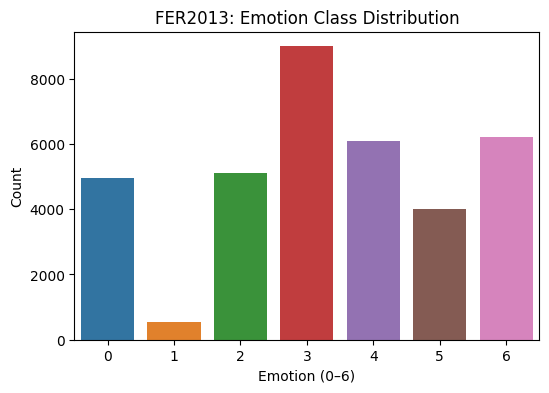

In [3]:
# === Cell 3a: EDA – Emotion class distribution ===
df = pd.read_csv('fer2013.csv')
plt.figure(figsize=(6,4))
sns.countplot(x='emotion', data=df)
plt.title("FER2013: Emotion Class Distribution")
plt.xlabel("Emotion (0–6)"); plt.ylabel("Count")
plt.show()


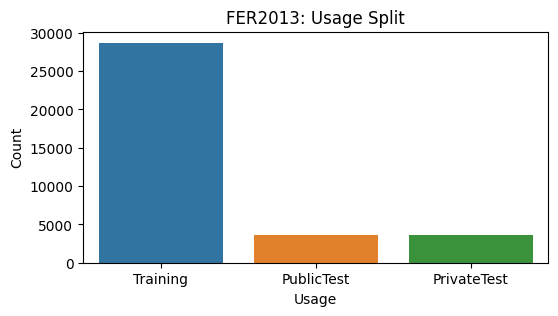

In [4]:
# === Cell 3b: EDA – Usage split ===
plt.figure(figsize=(6,3))
sns.countplot(x='Usage', data=df,
              order=['Training','PublicTest','PrivateTest'])
plt.title("FER2013: Usage Split"); plt.ylabel("Count")
plt.show()


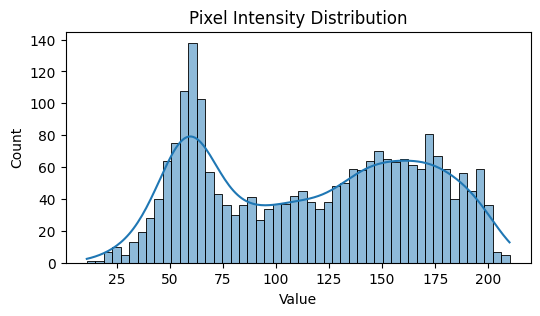

In [5]:
# === Cell 3c: EDA – Pixel intensity histogram (sample) ===
sample = np.fromstring(df.loc[0,'pixels'], dtype=int, sep=' ')
plt.figure(figsize=(6,3))
sns.histplot(sample, bins=50, kde=True)
plt.title("Pixel Intensity Distribution"); plt.xlabel("Value")
plt.show()


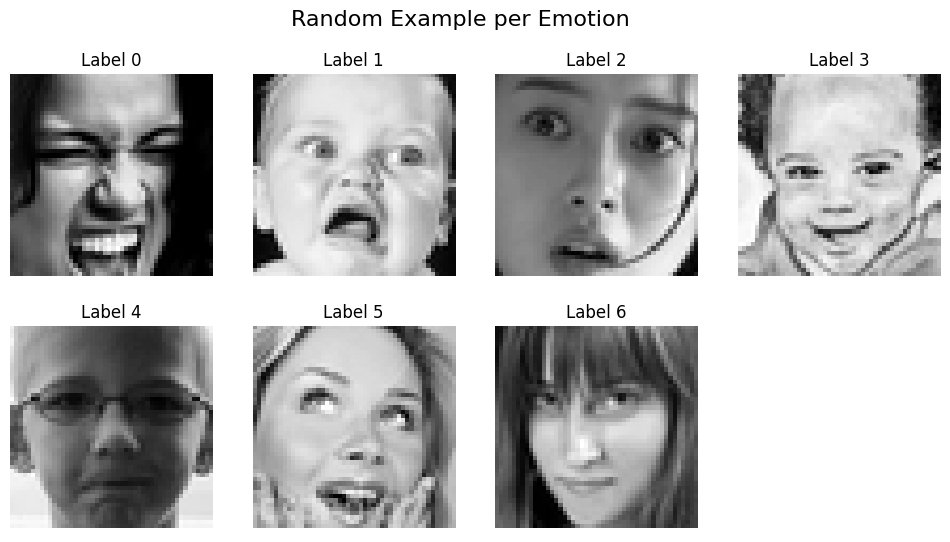

In [6]:
# === Cell 3d: EDA – One random example per emotion ===
fig, axes = plt.subplots(2,4, figsize=(12,6))
fig.suptitle("Random Example per Emotion", fontsize=16)
for emo in range(7):
    row = df[df.emotion==emo].sample(1).iloc[0]
    img = np.fromstring(row.pixels, dtype=int, sep=' ').reshape(48,48)
    ax = axes.flat[emo]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label {emo}")
    ax.axis('off')
axes.flat[-1].axis('off')
plt.show()


# Pipeline 3 - Data Preprocessing

## Step 4: Convert Pixel Data & Handle Malformed Entries
Transform pixel string data into proper image arrays by:
- Validating and filtering rows with exactly 2304 pixel values (48x48)
- Converting space-separated pixel strings to uint8 arrays
- Reshaping grayscale 48x48 images to RGB 48x48x3 format by duplicating channels
- Creating new 'pixels_arr' column with processed image arrays



In [7]:
# === Cell 4: Convert pixel strings → 48×48×3 uint8 arrays ===

# 4.1: Drop any rows where ‘pixels’ doesn’t split into exactly 2304 values
expected_len = 48*48
mask = df['pixels'].apply(lambda s: isinstance(s, str) and len(s.split()) == expected_len)
num_bad = len(df) - mask.sum()
if num_bad:
    print(f"Dropping {num_bad} malformed rows (pixel‑count ≠ {expected_len})")
df = df.loc[mask].reset_index(drop=True)

# 4.2: Now safely convert each string to a (48,48,3) uint8 image
def str_to_arr(s: str) -> np.ndarray:
    pixels = s.split()                               # list of length 2304
    arr48  = np.array(pixels, dtype=np.uint8)        # flat array
    arr48  = arr48.reshape(48, 48)                   # to 2D
    return np.stack((arr48,)*3, axis=-1)             # duplicate → 3 channels

df['pixels_arr'] = df['pixels'].apply(str_to_arr)

print("Success — all images are now (48,48,3):", df['pixels_arr'].iloc[0].shape)


Success — all images are now (48,48,3): (48, 48, 3)


## Step 5: Dataset Splitting & Class Weight Computation
Split data according to original FER2013 usage labels, extract image arrays and emotion labels, compute balanced class weights using scikit-learn to handle class imbalance, and precompute per-sample weights for training optimization.


In [8]:
# === Cell 5: Split data, compute class_weights, and precompute per‑sample weights ===
train_df = df[df['Usage']=='Training']
val_df   = df[df['Usage']=='PublicTest']
test_df  = df[df['Usage']=='PrivateTest']

def extract(df_):
    # X: (N,48,48,3) uint8 images; y: (N,) integer labels 0–6
    X = np.stack(df_['pixels_arr'].values)
    y = df_['emotion'].values.astype(int)
    return X, y

X_train, y_train = extract(train_df)
X_val,   y_val   = extract(val_df)
X_test,  y_test  = extract(test_df)

# compute balanced class weights {label: weight}
classes = np.arange(7)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

# precompute a sample_weights array to pass into .flow(...)
# sample_weights[i] = class_weights[y_train[i]]
sample_weights = np.array([ class_weights[label] for label in y_train ])

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Class weights:", class_weights)
print("Sample weights shape:", sample_weights.shape)


Shapes: (28709, 48, 48, 3) (3589, 48, 48, 3) (3589, 48, 48, 3)
Class weights: {0: 1.0266046844269623, 1: 9.406618610747051, 2: 1.0010460615781582, 3: 0.5684387684387684, 4: 0.8491274770777877, 5: 1.293372978330405, 6: 0.8260394187886635}
Sample weights shape: (28709,)


# Pipeline 4 - Advanced Data Pipeline Creation

## Step 6: Build TensorFlow Data Pipelines with Advanced Augmentation
Create sophisticated data pipelines featuring:
- Class-balanced oversampling to handle emotion imbalance
- Heavy data augmentation (flip, rotation, zoom, contrast, translation)
- Image resizing to 128x128 for MobileNetV2 compatibility
- MobileNetV2 preprocessing and one-hot encoding for focal loss
- Optimized batching and prefetching for training efficiency



In [9]:
# === Cell 6: build tf.data pipelines w/ heavy aug, class-balanced oversampling, and finite size ===

# 0) Constants
num_classes  = 7                  # FER2013 has 7 emotion labels
batch_size   = 32
img_height   = img_width = 128
AUTOTUNE     = tf.data.AUTOTUNE
n_train      = len(X_train)       # number of examples in your original training set

# 1) Base datasets from arrays
base_train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
base_val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   y_val))

# 2) Class-wise subsets for oversampling
class_ds = [
    base_train_ds.filter(lambda x, y, cls=cls: tf.equal(y, cls))
    for cls in range(num_classes)
]

# 3) Oversample minority classes
train_ds = tf.data.Dataset.sample_from_datasets(
    class_ds,
    weights=[1 / num_classes] * num_classes
)

# 4) Cap to exactly n_train examples so TF knows steps_per_epoch
train_ds = train_ds.take(n_train)

# 5) Strong in-graph augmentation
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),       # ±20%
    layers.RandomZoom(0.2),           # ±20%
    layers.RandomContrast(0.2),       # ±20%
    layers.RandomTranslation(0.1,0.1) # ±10% shift
], name="strong_augmentation")

# 6) Preprocessing functions
def preprocess_train(x, y):
    x = tf.cast(x, tf.float32)
    x = tf.image.resize(x, [img_height, img_width])
    x = aug(x, training=True)
    x = preprocess_input(x)
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)  # one-hot for focal loss
    return x, y

def preprocess_val(x, y):
    x = tf.cast(x, tf.float32)
    x = tf.image.resize(x, [img_height, img_width])
    x = preprocess_input(x)
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
    return x, y

# 7) Final pipelines: map → shuffle/batch/prefetch
train_ds = (
    train_ds
      .map(preprocess_train, num_parallel_calls=AUTOTUNE)
      .shuffle(10_000)
      .batch(batch_size)
      .prefetch(AUTOTUNE)
)

val_ds = (
    base_val_ds
      .map(preprocess_val, num_parallel_calls=AUTOTUNE)
      .batch(batch_size)
      .prefetch(AUTOTUNE)
)

print(f"Prepared train_ds (oversampled to {n_train} examples) and val_ds at {img_height}×{img_width}, batch_size={batch_size}")


Prepared train_ds (oversampled to 28709 examples) and val_ds at 128×128, batch_size=32


# Pipeline 5 - Model Architecture & Training

## Step 7: Build & Train MobileNetV2 with Transfer Learning
Implement advanced transfer learning approach:

- MobileNetV2 backbone with ImageNet weights and full fine-tuning enabled
- Custom classification head with batch normalization and dropout
- Cosine decay learning rate schedule with restarts
- Focal loss for handling class imbalance and hard examples
- Comprehensive callbacks (model checkpointing, early stopping)
- Training for up to 50 epochs with gradient clipping

In [10]:
# === Cell 7: Build, train, and save MobileNetV2 with lower LR schedule ===

# 1) Model definition
inp = Input(shape=(128, 128, 3), name="image_input")
backbone = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_tensor=inp,
    pooling="avg"
)
backbone.trainable = True

x = BatchNormalization(name="bn_head")(backbone.output)
x = Dropout(0.4, name="dropout_head")(x)
x = Dense(128, activation="relu", name="fc1")(x)
x = BatchNormalization(name="bn_fc1")(x)
x = Dropout(0.4, name="dropout_fc1")(x)
preds = Dense(num_classes, activation="softmax", name="predictions")(x)

model = Model(inputs=inp, outputs=preds, name="FER_MobileNetV2_full")
model.summary()

# 2) Learning-rate schedule: lower peak LR for full fine-tuning + gradient clipping
steps_per_epoch = len(X_train) // batch_size
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-4,      # reduced from 1e-3 to prevent loss explosion
    first_decay_steps=steps_per_epoch * 10,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-6,
)
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)

# 3) Compile with multi-class focal loss
model.compile(
    optimizer=optimizer,
    loss=tfa.losses.SigmoidFocalCrossEntropy(
        from_logits=False,
        alpha=0.25,
        gamma=2.0
    ),
    metrics=["categorical_accuracy"]
)

# 4) Callbacks: checkpoint best on val_categorical_accuracy, early-stop on val_loss
callbacks = [
    ModelCheckpoint(
        "best_mnv2_focal.h5",
        monitor="val_categorical_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

# 5) Train for up to 50 epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# 6) Save the best and final models
model.load_weights("best_mnv2_focal.h5")
model.save("FER_MobileNetV2_best.h5")
print("Best model saved to FER_MobileNetV2_best.h5")
files.download("FER_MobileNetV2_best.h5")

9406464/9406464 [==============================] - 2s 0us/step
Model: "FER_MobileNetV2_full"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['image_input[0][0]']            
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReL

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Pipeline 6 - Real-time Deployment

## Step 8: Interactive Webcam Emotion Recognition Interface
Deploy trained model in real-time application:
- Load best saved model and create optimized inference function
- Integrate OpenCV Haar Cascade for face detection
- Build JavaScript-powered webcam interface for Colab environment
- Implement real-time emotion prediction with face bounding boxes
- Support both webcam capture and image upload functionality
- Display emotion labels overlaid on detected faces

In [11]:
# === Cell 8: Left-Aligned Webcam & Upload UI with Continuous Emotion Prediction ===

# --- Constants ---
VIDEO_WIDTH, VIDEO_HEIGHT = 640, 480
IMAGE_SIZE = 128 # model input height/width

# --- Load model & build single-trace inference fn ---
model = load_model("FER_MobileNetV2_best.h5")
@tf.function
def predict_fn(x):
    # run the model in inference mode, returns (batch, 7) tensor
    return model(x, training=False)

# --- Emotion labels & face detector ---
emotion_labels = {
    0: "Angry", 1: "Disgust", 2: "Fear",
    3: "Happy", 4: "Sad",     5: "Surprise",
    6: "Neutral"
}
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# --- Helper: detect faces, preprocess, predict, annotate ---
def annotate_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(face_rgb, (IMAGE_SIZE, IMAGE_SIZE))
        inp = preprocess_input(resized.astype("float32"))
        inp = tf.expand_dims(inp, axis=0)  # shape (1, IMAGE_SIZE, IMAGE_SIZE, 3)
        preds = predict_fn(inp).numpy()[0]
        idx = int(np.argmax(preds))
        label = emotion_labels.get(idx, "Unknown")
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    return frame

# --- JavaScript UI: left-aligned video + bottom buttons ---
def start_webcam_ui():
    js = rf"""
    <script>
      const cid = 'emotion-container';
      document.getElementById(cid)?.remove();
      const c = document.createElement('div');
      c.id = cid;
      c.style.display = 'flex';
      c.style.flexDirection = 'column';
      c.style.alignItems = 'flex-start';
      c.style.margin = '10px';
      document.body.appendChild(c);

      const v = document.createElement('video');
      v.width = {VIDEO_WIDTH}; v.height = {VIDEO_HEIGHT}; v.autoplay = true;
      c.appendChild(v);

      navigator.mediaDevices.getUserMedia({{video:true}})
        .then(s => {{
          v.srcObject = s;
          setTimeout(() => {{
            const bar = document.createElement('div');
            bar.style.marginTop = '10px';
            c.appendChild(bar);

            const snap = document.createElement('button');
            snap.textContent = 'Capture Photo';
            bar.appendChild(snap);

            const upl = document.createElement('button');
            upl.textContent = 'Upload Image';
            bar.appendChild(upl);

            snap.onclick = () => {{
              const canvas = document.createElement('canvas');
              canvas.width = {VIDEO_WIDTH};
              canvas.height = {VIDEO_HEIGHT};
              canvas.getContext('2d').drawImage(v, 0, 0);
              const dataUrl = canvas.toDataURL('image/png');
              google.colab.kernel.invokeFunction('notebook.on_capture', [dataUrl], {{}});
            }};
            upl.onclick = () => {{
              google.colab.kernel.invokeFunction('notebook.on_upload', [], {{}});
            }};
          }}, 1000);
        }})
        .catch(e => alert('Webcam not accessible: ' + e));
    </script>
    """
    display(HTML(js))

# --- Callback: process a captured screenshot ---
def on_capture(dataUrl):
    header, encoded = dataUrl.split(",", 1)
    img = Image.open(io.BytesIO(base64.b64decode(encoded))).convert("RGB")
    frame = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    # frame is already VIDEO_WIDTH×VIDEO_HEIGHT
    annotated = annotate_frame(frame)
    cv2_imshow(annotated)

# --- Callback: process an uploaded image ---
def on_upload():
    uploaded = files.upload()
    for fname in uploaded:
        img = Image.open(fname).convert("RGB")
        frame = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        frame = cv2.resize(frame, (VIDEO_WIDTH, VIDEO_HEIGHT))
        annotated = annotate_frame(frame)
        cv2_imshow(annotated)

# --- Register callbacks & launch UI ---
output.register_callback('notebook.on_capture', on_capture)
output.register_callback('notebook.on_upload', on_upload)
start_webcam_ui()
